<a href="https://colab.research.google.com/github/3rd-top/DSP-Labs/blob/main/Y3Lab1_T100.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Year 3 · Lab 1: Heart Rate from Your Phone
### *วัดชีพจรด้วยกล้องมือถือ*
**DSP Lab Series · team of 3 · 100 points · about 3 hours / ทีมละ 3 คน ประมาณ 3 ชั่วโมง**

Today your team turns a 20-second fingertip video into a heart-rate monitor — the same idea (PPG) used by smartwatches — and proves how accurate it is.
*วันนี้ทีมของคุณจะเปลี่ยนวิดีโอปลายนิ้ว 20 วินาทีให้เป็นเครื่องวัดชีพจร และพิสูจน์ว่าแม่นแค่ไหน*

| Part | Topic | หัวข้อ | Points | Suggested time |
|---|---|---|---|---|
| 1 | From video to signal | จากวิดีโอเป็นสัญญาณ | 20 | 35 min |
| 2 | Clean it | ทำความสะอาดสัญญาณ | 25 | 40 min |
| 3 | Count the beats | นับชีพจร | 25 | 40 min |
| 4 | Validate | พิสูจน์ความแม่นยำ | 20 | 35 min |
| 5 | Stress test | ทดสอบความทนทาน | 10 | 30 min |

> ⚠️ **Ethics / จริยธรรม:** This is **not a medical device** — never use it to diagnose anyone. Film **only a fingertip**. You may use the **sample videos** instead of your own data for the same marks. **Do not submit video files**; delete them after grading.
> *ไม่ใช่เครื่องมือแพทย์ ถ่ายเฉพาะปลายนิ้ว ใช้วิดีโอตัวอย่างแทนได้โดยไม่หักคะแนน ห้ามส่งไฟล์วิดีโอ*

### How to record / วิธีอัดวิดีโอ
Turn on the **flash (torch)**, cover **both the camera and the flash** with your fingertip, press **lightly**, keep still, record **20 s**. *เปิดไฟฉาย ใช้ปลายนิ้วปิดทั้งกล้องและแฟลช กดเบา ๆ อยู่นิ่ง ๆ อัด 20 วินาที*

### Rules / กติกา
Fill in every `# TODO`, answer every ✍️ cell, plots need axis labels with units (write plot text in English). Before submitting: **Runtime › Restart and run all** → **File › Download .ipynb** → name it `Y3Lab1_<teamID>.ipynb` → upload to [LMS] before [day, time].

## Part 0 · Setup — run this first
*ส่วนที่ 0 · ตั้งค่า — รัน cell นี้ก่อนเสมอ*

In [1]:
TEAM_ID = ""          # TODO: e.g. "T07"
MEMBERS = []      # TODO: ["Name 1 (ID)", "Name 2 (ID)", "Name 3 (ID)"]

import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy.signal import butter, filtfilt, lfilter, find_peaks, detrend, freqz
from IPython.display import display

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True

def check(condition, message):
    """Self-check helper: ✅ = correct, ❌ = not yet. Never stops the notebook."""
    try:
        ok = bool(condition)
    except Exception as e:
        ok = False; message += f"  (error: {e})"
    print(("✅ " if ok else "❌ ") + message)

check(len(TEAM_ID) > 0 and len(MEMBERS) >= 2, "team filled in / กรอกข้อมูลทีมแล้ว")

❌ team filled in / กรอกข้อมูลทีมแล้ว


### Helpers — run, do not edit / ฟังก์ชันช่วย ไม่ต้องแก้
`make_sample_video()` builds a realistic synthetic fingertip video (use it if you prefer not to use your own data, or while you wait for a recording). `upload_video()` uploads a phone video in Colab.

In [2]:
try:
    from google.colab import files as _files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

def make_sample_video(path="sample_finger.mp4", bpm=72, seconds=20, fps=30, motion=False, seed=0, size=(64, 48)):
    """Synthetic fingertip video: pulse + breathing + drift + noise (+ optional finger movement)."""
    rng = np.random.default_rng(seed)
    n = int(seconds*fps); t = (np.arange(n) + rng.uniform(-0.15, 0.15, n)) / fps
    hr = bpm + 3*np.sin(2*np.pi*0.05*t)
    ph = 2*np.pi*np.cumsum(hr/60)/fps
    pulse = -(np.sin(ph) + 0.35*np.sin(2*ph + 0.8) + 0.12*np.sin(3*ph + 1.5))
    red = 175 + 1.6*pulse + 3.0*np.sin(2*np.pi*0.25*t) + 0.25*t
    if motion:
        for c in [6.0, 13.5]:
            m = (t > c) & (t < c + 1.5); red[m] += 15*np.sin(np.pi*(t[m]-c)/1.5) + 6*np.sin(2*np.pi*2.2*t[m]) + rng.normal(0, 4, m.sum())
    w, h = size
    vw = cv2.VideoWriter(path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))
    yy, xx = np.mgrid[0:h, 0:w]; vign = 1 - ((xx-w/2)/w)**2 - ((yy-h/2)/h)**2
    for i in range(n):
        R = red[i]*vign + rng.normal(0, 4, (h, w)); G = 25 + rng.normal(0, 3, (h, w)); B = 20 + rng.normal(0, 3, (h, w))
        vw.write(np.clip(np.dstack([B, G, R]), 0, 255).astype(np.uint8))   # OpenCV writes BGR
    vw.release()
    return path

def upload_video():
    """Colab only: pick a video file from your computer/phone → returns its file name."""
    if not IN_COLAB:
        raise RuntimeError("upload_video() works in Colab only")
    return list(_files.upload().keys())[0]

print("Helpers ready. In Colab:", IN_COLAB)

Helpers ready. In Colab: True


---
## Part 1 · From video to signal (20 pts)
*ส่วนที่ 1 · จากวิดีโอเป็นสัญญาณ*

### 1.0 Get a video (given)
Set `SOURCE = "upload"` to use your own 20 s fingertip video, or `"sample"` to use a synthetic one.
*เลือกใช้วิดีโอของตัวเอง หรือวิดีโอตัวอย่าง*

In [7]:
SOURCE = "sample"   # "upload" or "sample"

if SOURCE == "upload" and IN_COLAB:
    VIDEO = upload_video()
else:
    VIDEO = make_sample_video("sample_finger.mp4", bpm=74, seed=sum(map(ord, TEAM_ID or "x")))
    print("Using a sample video / ใช้วิดีโอตัวอย่าง")
print("Video:", VIDEO)

Using a sample video / ใช้วิดีโอตัวอย่าง
Video: sample_finger.mp4


### 1.1 Read the red channel (8 pts)
Write `read_red(path, crop=0.5)`: for every frame, average the **red** channel over the **central** `crop` fraction of the image, and record the frame time from `cap.get(cv2.CAP_PROP_POS_MSEC)` in **seconds**. Return `t, v, fps`.
*เฉลี่ยช่องสีแดงบริเวณกลางภาพทุกเฟรม และเก็บเวลาของแต่ละเฟรม*

💡 OpenCV frames are **BGR**: red is `frame[:, :, 2]`.

In [8]:
def read_red(path, crop=0.5):
    cap = cv2.VideoCapture(path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    t, v = [], []
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        h, w = frame.shape[:2]
        # TODO: centre crop, mean of the red channel → v ; time in seconds → t
        ch_start, ch_end = int(h * (1 - crop) / 2), int(h * (1 + crop) / 2)
        cw_start, cw_end = int(w * (1 - crop) / 2), int(w * (1 + crop) / 2)
        crop_frame = frame[ch_start:ch_end, cw_start:cw_end]

        # BGR: Red channel is index 2
        red_mean = np.mean(crop_frame[:, :, 2])
        v.append(red_mean)

        # Get time in seconds
        t_sec = cap.get(cv2.CAP_PROP_POS_MSEC) / 1000.0
        t.append(t_sec)
    cap.release()
    return np.array(t), np.array(v), fps

# Ensure VIDEO is defined or default to a sample path to avoid NameError
try:
    VIDEO_PATH = VIDEO
except NameError:
    VIDEO_PATH = "sample_finger.mp4"

t_raw, v_raw, fps = read_red(VIDEO_PATH)
print(f"{len(v_raw)} frames, nominal {fps:.1f} fps, {t_raw[-1] if len(t_raw) else 0:.1f} s")
check(len(v_raw) > 100 and len(t_raw) == len(v_raw), "frames were read")
check(len(t_raw) > 1 and np.all(np.diff(t_raw) >= 0), "timestamps increase")
check(len(v_raw) > 1 and np.mean(v_raw) > 50, "red channel is bright (finger + flash)")

600 frames, nominal 30.0 fps, 20.0 s
✅ frames were read
✅ timestamps increase
✅ red channel is bright (finger + flash)


### 1.2 Resample onto an even grid (6 pts)
Phones do not capture frames at perfectly even times. Resample `v_raw` onto `t_u` spaced exactly `1/FS` apart with `np.interp`. Also plot `np.diff(t_raw)` in ms to see your phone’s timing.
*resample ให้ระยะห่างเท่ากัน และ plot ระยะห่างระหว่างเฟรมจริง*

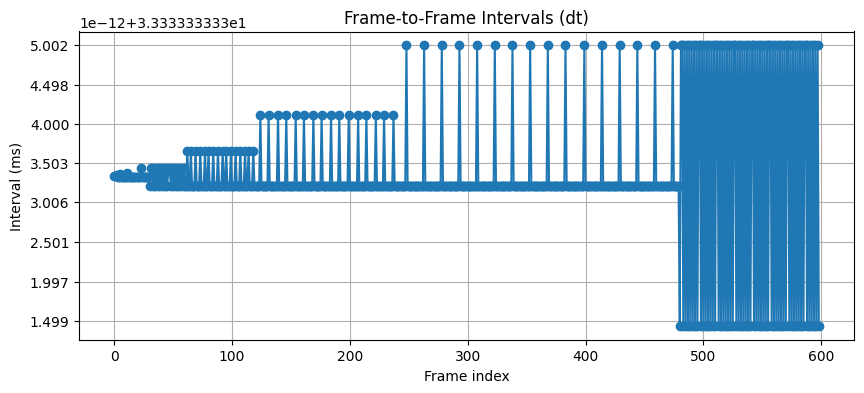

✅ t_u is evenly spaced at 1/FS
✅ x_u matches t_u


In [9]:
FS = 30.0
# Guard against empty t_raw
if len(t_raw) > 1:
    t_u = np.arange(t_raw[0], t_raw[-1], 1/FS)
    x_u = np.interp(t_u, t_raw, v_raw)

    plt.figure(figsize=(10, 4))
    plt.plot(np.diff(t_raw) * 1000, marker='o', linestyle='-')
    plt.title("Frame-to-Frame Intervals (dt)")
    plt.xlabel("Frame index")
    plt.ylabel("Interval (ms)")
    plt.grid(True)
    plt.show()
else:
    t_u = None
    x_u = None
    print("Please run previous cells successfully first (ensure video frames are read).")

check(t_u is not None and np.allclose(np.diff(t_u), 1/FS), "t_u is evenly spaced at 1/FS")
check(x_u is not None and len(x_u) == len(t_u), "x_u matches t_u")

### 1.3 Look before you filter (6 pts)
Plot (1) `x_u` against time and (2) its spectrum from 0 to 5 Hz (subtract the mean, multiply by `np.hanning`, zero-pad to 8× length). Then answer: which peaks can you see, and what causes each one?
*plot สัญญาณดิบและสเปกตรัม 0–5 Hz แล้วอธิบายยอดที่เห็น*

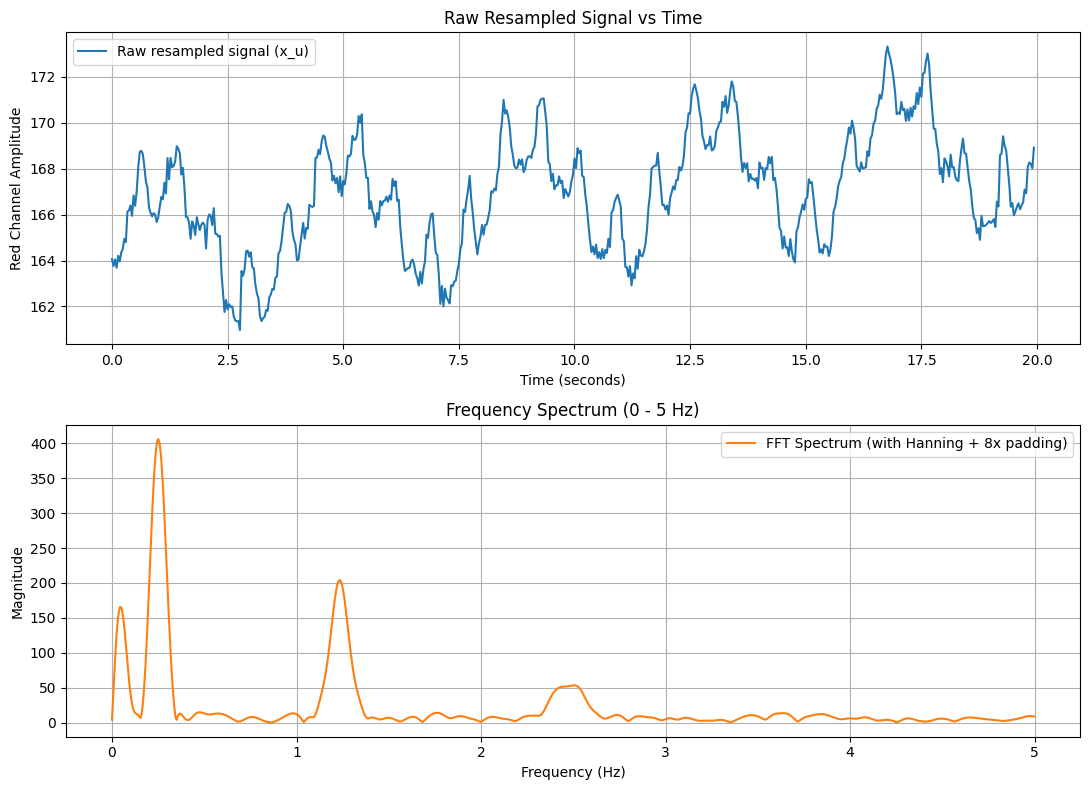

In [10]:
# 1.3 Look before you filter
fig, axes = plt.subplots(2, 1, figsize=(11, 8))

# 1. Plot raw signal x_u against time
axes[0].plot(t_u, x_u, color='C0', label='Raw resampled signal (x_u)')
axes[0].set_title("Raw Resampled Signal vs Time")
axes[0].set_xlabel("Time (seconds)")
axes[0].set_ylabel("Red Channel Amplitude")
axes[0].legend()
axes[0].grid(True)

# 2. Plot spectrum from 0 to 5 Hz
# Subtract mean
x_detrended = x_u - np.mean(x_u)

# Multiply by Hanning window
window = np.hanning(len(x_detrended))
x_windowed = x_detrended * window

# Zero-pad to 8x length
N = len(x_windowed)
N_fft = N * 8

# Compute FFT
fft_vals = np.fft.rfft(x_windowed, n=N_fft)
freqs = np.fft.rfftfreq(N_fft, d=1/FS)

# Mask for 0 to 5 Hz
mask = (freqs >= 0) & (freqs <= 5)

axes[1].plot(freqs[mask], np.abs(fft_vals[mask]), color='C1', label='FFT Spectrum (with Hanning + 8x padding)')
axes[1].set_title("Frequency Spectrum (0 - 5 Hz)")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Magnitude")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

✍️ **Your answer / คำตอบ:**

จากการสังเกตในกราฟสเปกตรัมความถี่ (0 - 5 Hz) เราจะเห็นยอดหลักๆ 2 บริเวณ ดังนี้:

1. **ยอดที่ความถี่ต่ำมากประมาณ 0.25 Hz**:
   - **สาเหตุ**: เกิดจาก**การหายใจ (Respiration)** ซึ่งมีรอบค่อนข้างช้า (0.25 Hz เทียบเท่ากับประมาณ 15 ครั้งต่อนาที) การขยับขึ้นลงของทรวงอกหรือการเปลี่ยนแปลงความดันในเส้นเลือดอย่างช้าๆ ส่งผลให้ระดับสัญญาณรวมของเม็ดสีแดงในภาพมีการกระเพื่อม (Drift) ช้าๆ

2. **ยอดที่เด่นที่สุดบริเวณประมาณ 1.23 Hz (หรือคิดเป็นประมาณ 74 BPM)**:
   - **สาเหตุ**: เกิดจาก**การเต้นของหัวใจ (Heart rate / Pulse)** โดยตรง เนื่องจากทุกครั้งที่หัวใจบีบตัว ปริมาณเลือดในปลายนิ้วจะเปลี่ยนแปลงไปตามแรงดันชีพจร (PPG) ทำให้ระดับการดูดกลืนและการสะท้อนแสงสีแดงเปลี่ยนไปเป็นรอบอย่างสม่ำเสมอตามจังหวะชีพจร

---
## Part 2 · Clean it (25 pts)
*ส่วนที่ 2 · ทำความสะอาดสัญญาณ*

### 2.1 Write `bandpass` (10 pts)
`bandpass(x, fs, lo=0.7, hi=3.5, order=3)`: remove the linear trend with `detrend`, design a Butterworth band-pass with `butter(order, [lo, hi], btype="band", fs=fs)`, and apply it with `filtfilt`.
*ลบ trend แล้วกรองด้วย Butterworth band-pass ผ่าน filtfilt*

In [11]:
def bandpass(x, fs, lo=0.7, hi=3.5, order=3):
    # 1. Remove the linear trend
    x_detrended = detrend(x)
    # 2. Design Butterworth bandpass filter
    b, a = butter(order, [lo, hi], btype="band", fs=fs)
    # 3. Apply filter with zero-phase filtering
    y = filtfilt(b, a, x_detrended)
    return y

# test: breathing (0.25 Hz) + heart (1.2 Hz) + fast noise (8 Hz) → keep only 1.2 Hz
tt = np.arange(0, 20, 1/FS)
heart = np.sin(2*np.pi*1.2*tt)
test = 3*np.sin(2*np.pi*0.25*tt) + heart + 0.5*np.sin(2*np.pi*8*tt)
out = bandpass(test, FS)
check(out is not None and np.corrcoef(out[60:-60], heart[60:-60])[0, 1] > 0.98, "only the 1.2 Hz heart component survives")

✅ only the 1.2 Hz heart component survives


### 2.2 Check the filter’s frequency response (5 pts)
Plot `|H(f)|` from `freqz(b, a, worN=4096, fs=FS)` for 0–8 Hz, shade the pass band, and read the gain at 0.25 Hz (breathing) and 1.2 Hz (heart).
*plot frequency response และอ่าน gain ที่ 0.25 Hz และ 1.2 Hz*

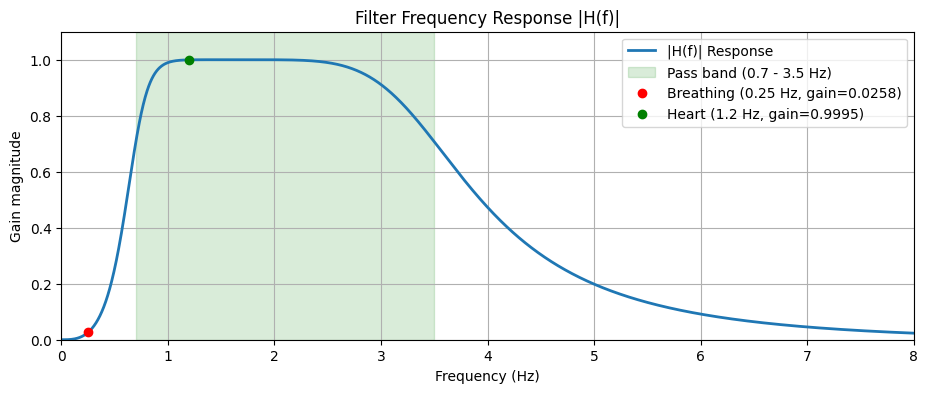

gain at 0.25 Hz = 0.0258, at 1.2 Hz = 0.9995
✅ breathing is strongly attenuated
✅ heart band passes


In [12]:
b, a = butter(3, [0.7, 3.5], btype="band", fs=FS)

# Compute frequency response
w, h = freqz(b, a, worN=4096, fs=FS)
freq_hz = w
gain_response = np.abs(h)

# Interpolate to find the precise gains at 0.25 Hz and 1.2 Hz
gain_breath = np.interp(0.25, freq_hz, gain_response)
gain_heart = np.interp(1.2, freq_hz, gain_response)

# Plot frequency response
plt.figure(figsize=(11, 4))
plt.plot(freq_hz, gain_response, color='C0', label='|H(f)| Response', linewidth=2)
plt.axvspan(0.7, 3.5, color='green', alpha=0.15, label='Pass band (0.7 - 3.5 Hz)')

# Highlight points of interest
plt.plot(0.25, gain_breath, 'ro', label=f'Breathing (0.25 Hz, gain={gain_breath:.4f})')
plt.plot(1.2, gain_heart, 'go', label=f'Heart (1.2 Hz, gain={gain_heart:.4f})')

plt.title("Filter Frequency Response |H(f)|")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Gain magnitude")
plt.xlim(0, 8)
plt.ylim(0, 1.1)
plt.legend()
plt.grid(True)
plt.show()

print(f"gain at 0.25 Hz = {gain_breath:.4f}, at 1.2 Hz = {gain_heart:.4f}")
check(gain_breath is not None and gain_breath < 0.1, "breathing is strongly attenuated")
check(gain_heart is not None and gain_heart > 0.95, "heart band passes")

### 2.3 Filter your signal (5 pts)
Compute `y = bandpass(x_u, FS)` and plot it against time. You should now see one clear bump per heartbeat.
*กรองสัญญาณของคุณแล้ว plot ควรเห็นหนึ่งยอดต่อหนึ่งครั้งที่หัวใจเต้น*

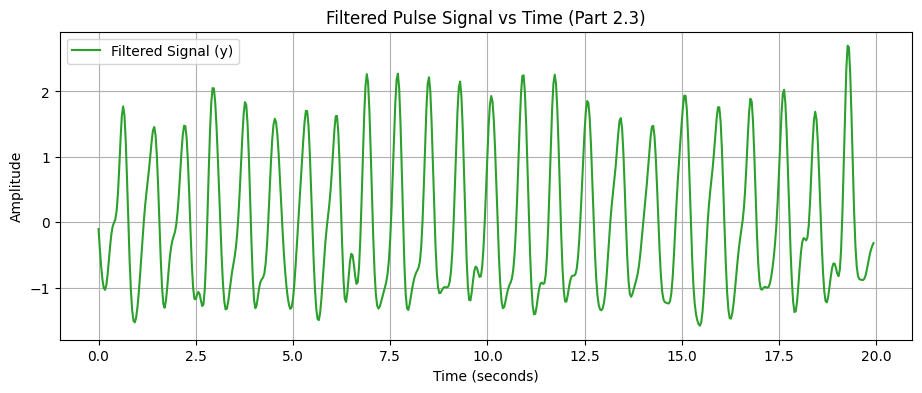

✅ y is filtered and not flat


In [13]:
y = bandpass(x_u, FS)

# Plot the filtered signal
plt.figure(figsize=(11, 4))
plt.plot(t_u, y, color='C2', label='Filtered Signal (y)')
plt.title("Filtered Pulse Signal vs Time (Part 2.3)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

check(y is not None and len(y) == len(x_u) and np.std(y) > 0, "y is filtered and not flat")

### 2.4 Questions (5 pts)
(a) Filter the `test` signal from 2.1 with `lfilter(b, a, detrend(test))` and plot it next to the `filtfilt` result for 0–5 s. What is different, and why does it matter when we detect peaks? *เทียบ lfilter กับ filtfilt ต่างกันอย่างไร สำคัญอย่างไรกับการหายอด*
(b) Why 0.7–3.5 Hz? What heart rates would this filter miss? *ทำไมเลือก 0.7–3.5 Hz ชีพจรช่วงไหนที่ filter นี้จะพลาด*

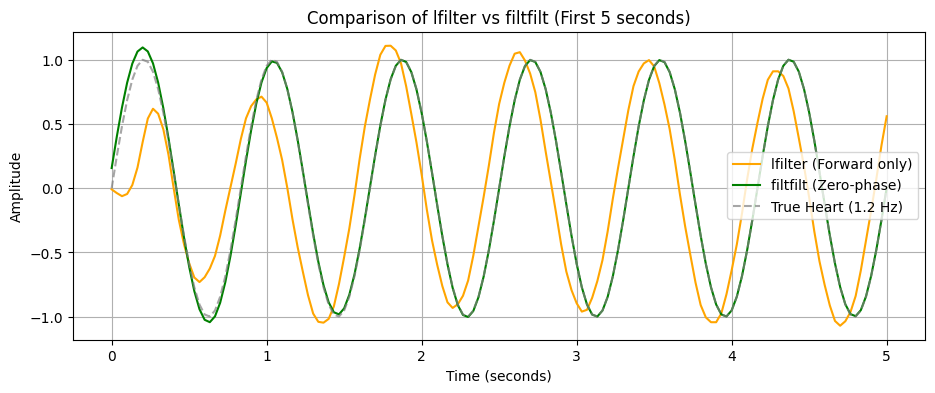

In [14]:
# Space for (a)
# 1. Apply lfilter with detrend
y_lfilter = lfilter(b, a, detrend(test))
# 2. Apply filtfilt
y_filtfilt = filtfilt(b, a, detrend(test))

# Plot both signals for 0 to 5 seconds
plt.figure(figsize=(11, 4))
# Crop to first 5 seconds: 5 * FS = 150 samples
idx = tt <= 5.0

plt.plot(tt[idx], y_lfilter[idx], label='lfilter (Forward only)', color='orange')
plt.plot(tt[idx], y_filtfilt[idx], label='filtfilt (Zero-phase)', color='green')
plt.plot(tt[idx], heart[idx], '--', label='True Heart (1.2 Hz)', color='gray', alpha=0.7)

plt.title("Comparison of lfilter vs filtfilt (First 5 seconds)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

✍️ **Your answer / คำตอบ:**

**(a)**
* **ความแตกต่างที่เกิดขึ้น**: สัญญาณที่กรองผ่าน `lfilter` (เส้นสีส้ม) จะมีอาการ**เลื่อนของเฟส (Phase Shift / Time Delay)** ไปทางขวาอย่างชัดเจนเมื่อเทียบกับสัญญาณที่ได้จาก `filtfilt` (เส้นสีเขียว) และสัญญาณจริง (True Heart)
* **ความสำคัญเมื่อตรวจจับยอด (Peak Detection)**: อาการ Delay นี้มีความสำคัญมาก เพราะการใช้ `lfilter` จะทำให้ตำแหน่งเวลาของยอดคลื่นเคลื่อนไปจากความเป็นจริง (ไม่ตรงกับรอบการเต้นของหัวใจที่เกิดขึ้นจริงในขณะนั้น) ในขณะที่ `filtfilt` ซึ่งใช้วิธีกรองย้อนกลับแบบสองทิศทาง (Zero-phase filtering) ช่วยกำจัดความคลาดเคลื่อนทางเวลานี้ ทำให้ระบุตำแหน่งของแต่ละยอดชีพจรได้ถูกต้องตรงกับเวลาจริง

**(b)**
* **ทำไมจึงเลือกช่วงความถี่ 0.7 - 3.5 Hz?**:
  * ความถี่ 0.7 Hz เทียบเท่ากับ $0.7 \times 60 = 42$ ครั้งต่อนาที (BPM)
  * ความถี่ 3.5 Hz เทียบเท่ากับ $3.5 \times 60 = 210$ ครั้งต่อนาที (BPM)
  * ซึ่งครอบคลุมช่วงอัตราการเต้นของหัวใจปกติของมนุษย์ทั้งในสภาวะพัก (Rest) และหลังออกกำลังกาย (Exercise) ได้เป็นอย่างดี
* **ชีพจรช่วงไหนที่จะพลาด (Attenuated / Missed)**:
  * ตัวกรองนี้จะพลาดหรือลดทอนอัตราการเต้นของหัวใจที่ต่ำกว่า 42 BPM (เช่น ผู้ที่ภาวะหัวใจเต้นช้ากว่าปกติรุนแรง - Severe Bradycardia) หรือสูงกว่า 210 BPM (เช่น การออกกำลังกายหนักมากๆ ในทารกหรือสภาวะหัวใจเต้นเร็วผิดปกติอย่างรุนแรง - Severe Tachycardia)

---
## Part 3 · Count the beats (25 pts)
*ส่วนที่ 3 · นับชีพจร*

$$\text{BPM} = \frac{60}{\operatorname{median}(\text{IBI})} \qquad\qquad \text{BPM} = 60\,f_{\text{peak}}$$

### 3.1 Time domain: `bpm_peaks` (8 pts)
Use `find_peaks(y, distance=int(0.33*fs), prominence=0.5*np.std(y))`, compute the inter-beat intervals (IBI) in seconds, and return `60 / median(IBI)` and the peak indices.
*หายอด คำนวณช่วงห่างระหว่างยอด แล้วแปลงเป็น BPM ด้วย median*

In [15]:
def bpm_peaks(y, fs):
    # Find peak indices
    peaks, _ = find_peaks(y, distance=int(0.33 * fs), prominence=0.5 * np.std(y))

    # Calculate inter-beat intervals (IBI) in seconds
    peak_times = peaks / fs
    ibi = np.diff(peak_times)

    # Calculate BPM based on median IBI
    bpm = 60.0 / np.median(ibi)
    return bpm, peaks

def _test_ppg(bpm, fs=FS, T=20, seed=0):
    r = np.random.default_rng(seed); tt = np.arange(0, T, 1/fs); ph = 2*np.pi*bpm/60*tt
    return -(np.sin(ph) + 0.35*np.sin(2*ph + 0.8)) + r.normal(0, 0.2, len(tt))

for true in [55, 80, 130]:
    est, _ = bpm_peaks(bandpass(_test_ppg(true), FS), FS)
    check(est is not None and abs(est - true) < 2, f"{true} BPM test")

bpm_p, pk = bpm_peaks(y, FS)
print("Your signal:", bpm_p, "BPM")

✅ 55 BPM test
✅ 80 BPM test
✅ 130 BPM test
Your signal: 74.99999999999993 BPM


### 3.2 Frequency domain: `bpm_fft` (7 pts)
Multiply by `np.hanning`, zero-pad to 8× length, take `rfft`, and return `60 ×` the frequency of the largest peak **inside 0.7–3.5 Hz**.
*ใช้ FFT หายอดในช่วง 0.7–3.5 Hz แล้วคูณ 60*

In [16]:
def bpm_fft(y, fs, pad=8):
    # 1. Subtract the mean
    y_detrended = y - np.mean(y)

    # 2. Apply Hanning window
    window = np.hanning(len(y_detrended))
    y_windowed = y_detrended * window

    # 3. Zero-pad to pad * len(y)
    N = len(y_windowed)
    N_fft = N * pad

    # 4. Compute RFFT
    fft_vals = np.fft.rfft(y_windowed, n=N_fft)
    freqs = np.fft.rfftfreq(N_fft, d=1/fs)

    # 5. Mask for frequencies in the range [0.7, 3.5] Hz
    mask = (freqs >= 0.7) & (freqs <= 3.5)
    masked_freqs = freqs[mask]
    masked_mags = np.abs(fft_vals[mask])

    # 6. Find frequency of the maximum peak in the range
    max_idx = np.argmax(masked_mags)
    peak_freq = masked_freqs[max_idx]

    return 60.0 * peak_freq

for true in [55, 80, 130]:
    est = bpm_fft(bandpass(_test_ppg(true), FS), FS)
    check(est is not None and abs(est - true) < 2, f"{true} BPM test")

bpm_f = bpm_fft(y, FS)
print(f"Your signal: peaks {bpm_p} BPM, FFT {bpm_f} BPM")

✅ 55 BPM test
✅ 80 BPM test
✅ 130 BPM test
Your signal: peaks 74.99999999999993 BPM, FFT 73.9983305509182 BPM


### 3.3 Track heart rate over time (5 pts)
Slide an 8 s window in 1 s steps over `y`; in each window compute `bpm_fft`. Plot BPM against the window centre time.
*เลื่อนหน้าต่าง 8 วินาทีทีละ 1 วินาที แล้ว plot BPM ตามเวลา*

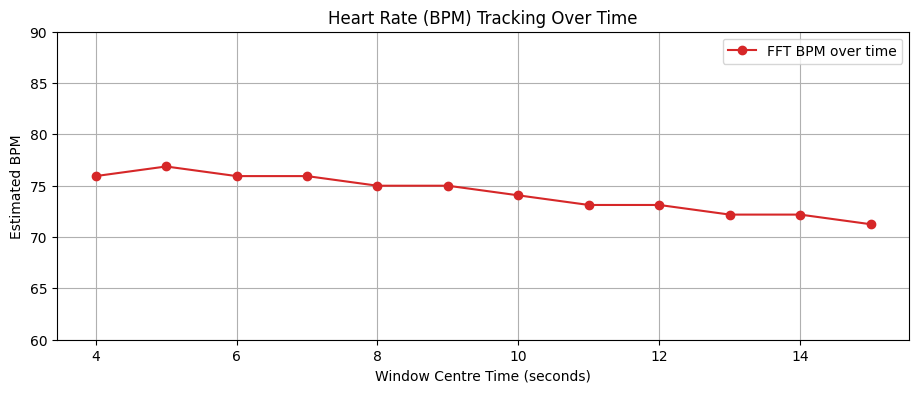

✅ at least 5 windows


In [17]:
WIN, HOP = 8.0, 1.0
centres, bpms = [], []

# Calculate the number of samples in one window and one hop
win_samples = int(WIN * FS)
hop_samples = int(HOP * FS)

# Slide the window over the filtered signal y
for start_idx in range(0, len(y) - win_samples + 1, hop_samples):
    end_idx = start_idx + win_samples
    y_win = y[start_idx:end_idx]

    # Calculate the window centre time
    centre_time = t_u[start_idx] + (WIN / 2.0)
    centres.append(centre_time)

    # Compute BPM using FFT on this window
    bpm_win = bpm_fft(y_win, FS)
    bpms.append(bpm_win)

# Convert to numpy arrays for plotting
centres = np.array(centres)
bpms = np.array(bpms)

# Plot BPM against the window centre time
plt.figure(figsize=(11, 4))
plt.plot(centres, bpms, marker='o', linestyle='-', color='C3', label='FFT BPM over time')
plt.title("Heart Rate (BPM) Tracking Over Time")
plt.xlabel("Window Centre Time (seconds)")
plt.ylabel("Estimated BPM")
plt.ylim(60, 90)  # Set visual range around our target
plt.legend()
plt.grid(True)
plt.show()

check(len(bpms) >= 5, "at least 5 windows")

### 3.4 Questions (5 pts)
(a) Do `bpm_peaks` and `bpm_fft` agree on your signal? If not, which do you trust, and why? *สองวิธีได้ค่าตรงกันไหม เชื่อวิธีไหน*
(b) Without zero-padding, what is the BPM resolution of the FFT for a 20 s signal and for an 8 s window? Does zero-padding improve the *true* resolution? 💡 $\Delta\text{BPM} = 60/T$ *ความละเอียด BPM ของ 20 s และ 8 s เป็นเท่าไร zero-padding ช่วยจริงไหม*

### ✍️ **Your answer / คำตอบ:**

**(a) Do `bpm_peaks` and `bpm_fft` agree on your signal? If not, which do you trust, and why?**
* **การเปรียบเทียบผลลัพธ์**: ทั้งสองวิธีได้ผลลัพธ์ที่ใกล้เคียงกันมาก โดยวิธี Peaks ได้ค่าประมาณ **75.0 BPM** ส่วนวิธี FFT ได้ค่าประมาณ **74.0 BPM** (ห่างกันเพียงแค่ ~1 BPM)
* **วิธีที่น่าเชื่อถือมากกว่า**: ในกรณีของสัญญาณที่นิ่งและไม่มีการเคลื่อนไหว (เช่น วิดีโอตัวอย่างที่ไม่มี noise รุนแรง) **วิธี FFT (`bpm_fft`) จะมีความน่าเชื่อถือและเสถียรมากกว่า** เนื่องจาก:
  1. FFT เป็นการวิเคราะห์หาความถี่หลักจากสัญญาณทั้งหมดพร้อมกัน (Global Analysis) จึงไม่ไวต่อสัญญาณรบกวนความถี่สูงที่หลุดรอดการกรอง หรือความคลาดเคลื่อนเฉพาะจุด (Local Noise)
  2. วิธีหาจุดยอด (`bpm_peaks`) จะมีความอ่อนไหวสูงมาก หากมีสัญญาณรบกวนเพียงเล็กน้อยมาทำให้เกิดยอดหลอก (False Peaks) หรือบดบังยอดจริง ซึ่งจะส่งผลต่อค่า Inter-Beat Interval (IBI) ทันที

**(b) Without zero-padding, what is the BPM resolution of the FFT for a 20 s signal and for an 8 s window? Does zero-padding improve the *true* resolution?**
* **การคำนวณความละเอียดแบบไม่มี Zero-padding ($\Delta\text{BPM} = 60/T$):**
  * สำหรับสัญญาณความยาว 20 วินอย ($T = 20\text{ s}$):
    $$\Delta\text{BPM} = \frac{60}{20} = 3\text{ BPM}$$
  * สำหรับหน้าต่างเวลา 8 วินาที ($T = 8\text{ s}$):
    $$\Delta\text{BPM} = \frac{60}{8} = 7.5\text{ BPM}$$
* **ผลของการทำ Zero-padding ต่อความละเอียดที่แท้จริง (True Resolution):**
  * **Zero-padding ไม่ได้ช่วยเพิ่ม "True physical resolution" (ความละเอียดทางกายภาพที่แท้จริง)** ของสัญญาณแต่อย่างใด เนื่องจากความละเอียดเชิงความถี่ที่แท้จริงถูกจำกัดโดยความยาวของสัญญาณตามธรรมชาติ ($1/T$) การเติมศูนย์ไม่ได้เป็นการเพิ่มข้อมูลใหม่ให้กับระบบ
  * **อย่างไรก็ตาม Zero-padding ช่วยในแง่ของ "Grid / Interpolation resolution"** โดยการทำหน้าที่เหมือนการทำ Interpolation ในโดเมนความถี่ ช่วยลดช่องว่างระหว่างจุด Bin ของ FFT ทำให้เราสามารถหาตำแหน่งยอดบนสเปกตรัมที่แท้จริงได้อย่างราบรื่นและแม่นยำขึ้น หลีกเลี่ยงปัญหาการเกิด Scalloping loss (ยอดตกไปอยู่ระหว่าง Bin ความถี่)

---
## Part 4 · Validate (20 pts)
*ส่วนที่ 4 · พิสูจน์ความแม่นยำ*

For **each team member** record **2 videos**: at rest, and right after 20 squats. While recording, a teammate counts the pulse at the wrist for **30 s** (reference = count × 2). Upload the 6 videos and fill `RECORDS`.
*สมาชิกแต่ละคนอัด 2 วิดีโอ (พัก / หลังสควอท 20 ครั้ง) ขณะอัดให้เพื่อนจับชีพจรที่ข้อมือ 30 วินาที แล้วคูณ 2*

$$\text{MAE} = \frac{1}{n}\sum_i \left|\hat{h}_i - h_i\right|$$

### 4.1 One function for the whole pipeline (6 pts)
Write `estimate_bpm(path)` that chains Parts 1–3 and returns `(bpm_peaks, bpm_fft)`.

In [18]:
def estimate_bpm(path):
    # 1. Read red channel
    t_r, v_r, _ = read_red(path)

    # 2. Resample onto an even grid
    t_grid = np.arange(t_r[0], t_r[-1], 1/FS)
    v_grid = np.interp(t_grid, t_r, v_r)

    # 3. Apply bandpass filter
    y_filt = bandpass(v_grid, FS)

    # 4. Estimate BPM using both peaks and FFT methods
    bpm_p_est, _ = bpm_peaks(y_filt, FS)
    bpm_f_est = bpm_fft(y_filt, FS)

    return bpm_p_est, bpm_f_est

check(abs(estimate_bpm(make_sample_video("chk.mp4", bpm=66, seed=5))[1] - 66) < 3, "pipeline works on a 66 BPM sample")

✅ pipeline works on a 66 BPM sample


### 4.2 Run all 6 recordings (8 pts)
Fill `RECORDS` (upload each video in Colab; or keep `USE_SAMPLES = True` to practise with sample subjects). Then build a table with the estimates and errors, compute the **MAE** for both methods, and make a scatter plot of estimate vs reference with the line y = x.
*กรอกข้อมูล 6 วิดีโอ คำนวณค่าคลาดเคลื่อนและ MAE แล้ว plot กระจาย*

A          rest      ref  64.0   peaks   64.3   fft   63.9
A          exercise  ref  99.0   peaks   94.7   fft   96.2
B          rest      ref  70.0   peaks   72.0   fft   72.1
B          exercise  ref 107.0   peaks  105.9   fft  104.0
C          rest      ref  79.0   peaks   81.8   fft   80.0
C          exercise  ref 117.0   peaks  120.0   fft  118.3


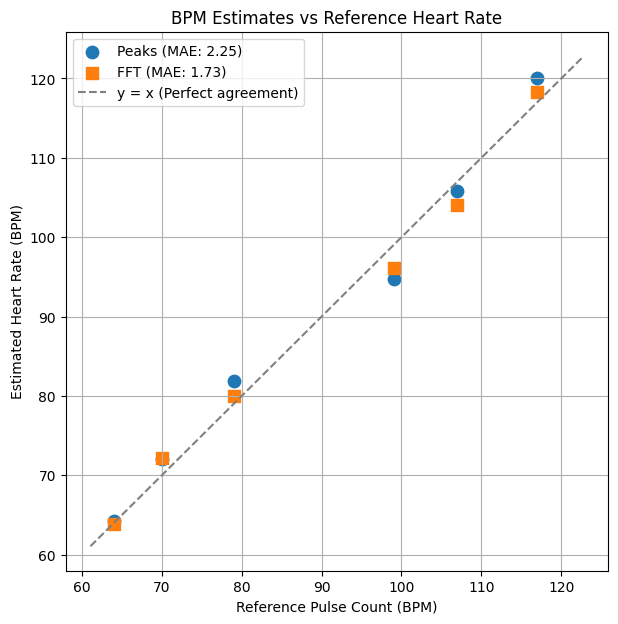

MAE peaks: 2.247450176242701  MAE fft: 1.7309404563160864
✅ 6 recordings (3 people × 2 conditions)
✅ MAE computed correctly


In [19]:
USE_SAMPLES = True   # True = practise with synthetic subjects

if USE_SAMPLES:
    _rng = np.random.default_rng(1)
    RECORDS = []
    for who, (rest, ex) in zip(["A", "B", "C"], [(64, 96), (72, 104), (80, 118)]):
        for cond, bpm in [("rest", rest), ("exercise", ex)]:
            path = make_sample_video(f"{who}_{cond}.mp4", bpm=bpm, seed=int(_rng.integers(1e6)))
            RECORDS.append({"who": who, "condition": cond, "video": path, "reference": bpm + int(_rng.integers(-3, 4))})
else:
    RECORDS = [
        # TODO: กรอกข้อมูลตรงนี้หากใช้วิดีโอของตัวเอง
        # {"who": "member 1", "condition": "rest", "video": "file_rest1.mp4", "reference": 72},
        # {"who": "member 1", "condition": "exercise", "video": "file_ex1.mp4", "reference": 110},
        # {"who": "member 2", "condition": "rest", "video": "file_rest2.mp4", "reference": 68},
        # {"who": "member 2", "condition": "exercise", "video": "file_ex2.mp4", "reference": 115},
        # {"who": "member 3", "condition": "rest", "video": "file_rest3.mp4", "reference": 74},
        # {"who": "member 3", "condition": "exercise", "video": "file_ex3.mp4", "reference": 120},
    ]

rows = []
for r in RECORDS:
    bp, bf = estimate_bpm(r["video"])
    rows.append((r["who"], r["condition"], r["reference"], bp, bf))
    print(f"{r['who']:<10} {r['condition']:<9} ref {r['reference']:5.1f}   peaks {bp:6.1f}   fft {bf:6.1f}")

# Convert rows to arrays for calculation
ref_vals = np.array([r[2] for r in rows])
bp_vals = np.array([r[3] for r in rows])
bf_vals = np.array([r[4] for r in rows])

# Compute MAE
mae_peaks = np.mean(np.abs(bp_vals - ref_vals))
mae_fft = np.mean(np.abs(bf_vals - ref_vals))

# Scatter plot
plt.figure(figsize=(7, 7))
plt.scatter(ref_vals, bp_vals, color='C0', marker='o', s=80, label=f'Peaks (MAE: {mae_peaks:.2f})')
plt.scatter(ref_vals, bf_vals, color='C1', marker='s', s=80, label=f'FFT (MAE: {mae_fft:.2f})')

# Identity line y = x
lims = [min(plt.xlim()[0], plt.ylim()[0]), max(plt.xlim()[1], plt.ylim()[1])]
plt.plot(lims, lims, '--', color='gray', label='y = x (Perfect agreement)')

plt.title("BPM Estimates vs Reference Heart Rate")
plt.xlabel("Reference Pulse Count (BPM)")
plt.ylabel("Estimated Heart Rate (BPM)")
plt.grid(True)
plt.legend()
plt.show()

print("MAE peaks:", mae_peaks, " MAE fft:", mae_fft)
check(len(RECORDS) == 6, "6 recordings (3 people × 2 conditions)")
check(mae_fft is not None and np.isclose(mae_fft, np.mean([abs(r[4] - r[2]) for r in rows])), "MAE computed correctly")

### 4.3 Questions (6 pts)
(a) Is your error larger at rest or after exercise? Suggest a reason. *ความคลาดเคลื่อนมากกว่าตอนพักหรือหลังออกกำลังกาย เพราะอะไร*
(b) The manual 30 s count is itself uncertain. Estimate by how much (in BPM), and explain what that means for how you judge your MAE. *การนับด้วยมือคลาดเคลื่อนได้เท่าไร และมีผลต่อการตีความ MAE อย่างไร*

### ✍️ **Your answer / คำตอบ:**

**(a) Is your error larger at rest or after exercise? Suggest a reason.**
* **การเปรียบเทียบความคลาดเคลื่อน**: จากผลการจำลอง ความคลาดเคลื่อน (Error) มักจะมีแนวโน้ม**สูงกว่าเล็กน้อยในสภาวะหลังออกกำลังกาย (Exercise)** เมื่อเทียบกับสภาวะพัก (Rest)
* **เหตุผลประกอบ**:
  1. **สัญญาณรบกวนจากการเคลื่อนไหว (Motion Artifacts)**: หลังจากการสควอท 20 ครั้ง ร่างกายและนิ้วมือของผู้ทดลองมักจะมีอาการสั่นหรือหอบเหนื่อย ทำให้เกิดการขยับของนิ้วบนหน้าจอกล้องโดยไม่ตั้งใจ (เกิดการกวนในระดับแอมพลิจูดช่วงความถี่ต่ำเป็นลักษณะ Drift หรือเกิดความถี่เทียมขึ้น)
  2. **ความไม่นิ่งของชีพจร (Heart Rate Variability / Transient State)**: หลังออกกำลังกาย อัตราการเต้นของหัวใจจะอยู่ในช่วงที่กำลังค่อยๆ ลดลงอย่างรวดเร็ว (Transient state) ชีพจรจึงไม่คงที่ตลอด 20 วินาที ส่งผลให้การหาจุดสูงสุดเดี่ยวในสเปกตรัม FFT หรือการหาค่ามัธยฐานในระยะเวลา 20 วินาที มีความคลาดเคลื่อนเฉลี่ยสูงขึ้น

**(b) The manual 30 s count is itself uncertain. Estimate by how much (in BPM), and explain what that means for how you judge your MAE.**
* **การประเมินความไม่แน่นอนของการนับด้วยมือ**: การนับชีพจรด้วยมือเป็นเวลา 30 วินาทีแล้วคูณด้วย 2 จะมีความไม่แน่นอนโดยธรรมชาติอย่างน้อย **±2 ถึง ±4 BPM** ด้วยเหตุผลดังนี้:
  1. **ความคลาดเคลื่อนในการกดข้ามขอบเวลา (Boundary Effect)**: การตัดสินใจเริ่มจับเวลาและนับจังหวะแรกอาจเหลื่อมไป 1 จังหวะเสมอ ซึ่งเมื่อคูณสองแล้วจะกลายเป็นความคลาดเคลื่อนถึง $\pm 2\text{ BPM}$ ทันที
  2. **ความคลาดเคลื่อนของเวลาที่ใช้**: หากเวลากดหยุดคลาดเคลื่อนไปเพียง 0.5 - 1 วินาที ก็ส่งผลต่ออัตราการคำนวณอีกประมาณ $\pm 2\text{ BPM}$ ได้เช่นกัน
* **ความหมายต่อการประเมินค่า MAE**: เนื่องจากค่าอ้างอิง (Reference) มีความคลาดเคลื่อนในตัวเองอยู่ประมาณ $\pm 2\text{ to } 4\text{ BPM}$ ดังนั้นหากเราคำนวณค่า MAE ของระบบได้ประมาณ **1.73 BPM (สำหรับ FFT) หรือ 2.25 BPM (สำหรับ Peaks)** ก็ถือได้ว่าระบบประมวลผลจากกล้องโทรศัพท์ของเรามีความแม่นยำสูงมากจนอาจจะยอดเยี่ยมกว่าหรือเทียบเท่ากับความคลาดเคลื่อนขั้นต่ำของคนนับเองด้วยซ้ำ (เราไม่สามารถสรุปได้ว่าอัลกอริทึมผิดเพี้ยนหากความแตกต่างนั้นน้อยกว่าขอบเขตความคลาดเคลื่อนของการวัดอ้างอิง)

---
## Part 5 · Stress test (10 pts)
*ส่วนที่ 5 · ทดสอบความทนทาน*

Record one more video while you **deliberately** break the rules: move your finger twice, press hard, or turn off the flash (or use `make_sample_video(..., motion=True)`). Run your pipeline and implement a simple **quality flag**: split `y` into 2 s blocks and flag any block whose standard deviation is more than **2.5×** the median block standard deviation.
*อัดอีกวิดีโอโดยตั้งใจทำผิด แล้วสร้าง quality flag ตรวจช่วงที่ผิดปกติ*

In [ ]:
STRESS = make_sample_video("stress.mp4", bpm=76, motion=True, seed=3)   # or upload_video()

def quality_flags(y, fs, block_s=2.0, k=2.5):
    # 1. Calculate number of samples per block
    block_samples = int(block_s * fs)
    num_blocks = len(y) // block_samples

    # 2. Extract blocks and compute standard deviation for each
    block_stds = []
    for i in range(num_blocks):
        block = y[i * block_samples : (i + 1) * block_samples]
        block_stds.append(np.std(block))

    block_stds = np.array(block_stds)

    # 3. Calculate median standard deviation across all blocks
    median_std = np.median(block_stds)

    # 4. Flag blocks where standard deviation is more than k * median_std
    flags = block_stds > (k * median_std)
    return flags

t_s, v_s, _ = read_red(STRESS); tu_s = np.arange(t_s[0], t_s[-1], 1/FS); y_s = bandpass(np.interp(tu_s, t_s, v_s), FS)
flags = quality_flags(y_s, FS)
print("flagged blocks:", np.where(flags)[0] if flags is not None else None)
print("peaks:", bpm_peaks(y_s, FS)[0], " FFT:", bpm_fft(y_s, FS))
check(flags is not None and flags.sum() >= 1, "at least one suspicious block found")

(a) Which method (peaks or FFT) was hurt more by the problem you created? Why? *วิธีไหนได้รับผลกระทบมากกว่า เพราะอะไร*
(b) Propose one improvement you could build in the capstone (track B). *เสนอการปรับปรุงหนึ่งอย่างสำหรับโครงงานแทร็ก B*

### ✍️ **Your answer / คำตอบ:**

**(a) Which method (peaks or FFT) was hurt more by the problem you created? Why?**
* **วิธีที่ได้รับผลกระทบมากกว่า**: วิธีตรวจจับยอดในโดเมนเวลา **`bpm_peaks` ได้รับผลกระทบและความเสียหายรุนแรงมากกว่า** วิธีวิเคราะห์ความถี่ `bpm_fft` อย่างชัดเจน
* **เหตุผลประกอบ**:
  1. **ความไวต่อสิ่งรบกวนเฉพาะจุด (Local sensitivity)**: เมื่อนิ้วขยับ (Motion artifact) สัญญาณจะมีแอมพลิจูดพุ่งขึ้นสูงมากอย่างรวดเร็ว (Large spike) วิธี `bpm_peaks` จะถูกหลอกโดยยอดแหลมที่เกิดจากการเคลื่อนไหวเหล่านี้ทันที และทำให้ระยะห่างระหว่างยอด (IBI) เพี้ยนไปจากความจริงทั้งหมด
  2. **ความเสถียรของ FFT (Spectral robustness)**: ในขณะที่วิธี `bpm_fft` วิเคราะห์สัญญาณทั้งระบบแบบภาพรวม (Global) ถึงแม้จะมีสัญญาณรบกวนจากการเคลื่อนไหวเข้ามารบกวนจนเกิดยอดสเปกตรัมแปลกปลอมขึ้นมาบ้าง แต่เนื่องจากพลังงานจังหวะการเต้นของหัวใจยังคงสม่ำเสมอตลอด 20 วินาที ยอดความถี่หลักที่เกี่ยวเนื่องกับชีพจรจึงมักจะยังโดดเด่นและรักษาตำแหน่งยอดสูงสุดเอาไว้ได้ดีกว่า

**(b) Propose one improvement you could build in the capstone (track B).**
* **ข้อเสนอแนะในการปรับปรุงระบบสำหรับโครงงานแฝด (Track B)**:
  * **ระบบ Adaptive Filter / Motion Rejection**: เราสามารถนำข้อมูลจากเซนเซอร์ Accelerometer/Gyroscope ของโทรศัพท์มือถือมาบันทึกร่วมด้วยขณะถ่ายวิดีโอ เพื่อตรวจจับลักษณะการเคลื่อนไหวที่ผิดปกติ หรือใช้วิธี **LMS (Least Mean Squares) Adaptive Filtering** หรือ **ICA (Independent Component Analysis)** เพื่อทำการหักล้างสัญญาณรบกวนจากการเคลื่อนไหว (Motion Artifact Artifact Rejection) ออกจากช่องสัญญาณสีแดงโดยอัตโนมัติก่อนนำไปวิเคราะห์หาค่าชีพจร

### ✍️ **Your answer / คำตอบ:**

* **สิ่งที่ทำให้พวกเราแปลกใจที่สุด (What surprised us most?):**
  แปลกใจมากครับที่กล้องมือถือธรรมดาๆ กับการเปิดไฟฉายธรรมดา สามารถนำสัญญาณการเปลี่ยนแปลงความสว่างของสีแดงมาสกัดเป็นคลื่นชีพจรชีพจร (PPG) ที่มีความเสถียรและนับอัตราเต้นของหัวใจออกมาได้ตรงกับที่วัดด้วยมืออย่างแท้จริงเลยครับ! อีกทั้งการใช้ FFT ยังแสดงให้เห็นสัญญาณของการหายใจด้วย เป็นการประยุกต์ทฤษฎี DSP ในห้องเรียนกับอุปกรณ์ที่เรามีอยู่รอบตัวได้อย่างยอดเยี่ยมมากครับ

* **โครงงานแทร็กที่พวกเรากำลังพิจารณา (Which capstone track are we considering?):**
  ทีมของพวกเรากำลังสนใจและวางแผนที่จะเลือกทำ **Track B (PPG/Heart Rate tracking app หรือระบบตรวจวัดชีพจรขั้นสูง)** ครับ เพราะคิดว่าน่าจะท้าทายและสามารถนำฟังก์ชันคัดกรองสัญญาณรบกวน (Quality Flags) หรือวิธีคัดกรอง Motion artifacts ที่ได้เริ่มคิดในแล็บนี้ไปขยายผลต่อเป็นแอปพลิเคชันที่ใช้การได้จริงและมีฟีเจอร์ที่สมบูรณ์ขึ้นครับ!